# Lab 5 : Textual Feature Representation

## 65070501050 | Wongsatorn Sungsilapawech

## Preprocess

In [2]:
import pickle
import pandas as pd

In [3]:
data = pd.read_pickle('consumer_complaint_dataset.data', compression='gzip')

In [4]:
data.head()

,topic,input
0,Debt collection,transworld systems inc. \nis trying to collect...
1,"Credit reporting, credit repair services, or o...",I would like to request the suppression of the...
2,Debt collection,"Over the past 2 weeks, I have been receiving e..."
3,"Credit reporting, credit repair services, or o...",I HAD FILED WITH CFPB ON XX/XX/XXXX19 TO HAVE ...
4,"Credit reporting, credit repair services, or o...",I have several accounts that the balance is in...


> **Note** due to heavy resource used, lead to length of compilation time too long, I set the data to the first 50k

In [5]:
data = data[:50000]

In [6]:
data['input']

0        transworld systems inc. \nis trying to collect...
1        I would like to request the suppression of the...
2        Over the past 2 weeks, I have been receiving e...
3        I HAD FILED WITH CFPB ON XX/XX/XXXX19 TO HAVE ...
4        I have several accounts that the balance is in...
                               ...                        
49995    I disputed an account on my credit report from...
49996    This account was paid in full in XX/XX/2018 an...
49997    XXXX XXXX XXXX XXXX I don't know, I just looke...
49998    I have not received confirmation nor certified...
49999    I payed navient {$2000.00} ( in 2014 ) to make...
Name: input, Length: 50000, dtype: object

### Clean punctuations

In [7]:
import re
def clean_punctuation(text):
    # Define a regular expression pattern to match punctuation and special characters
    # Matches any character that is not a word character (\w), space (\s), or underscore (_)
    punctuation_pattern = re.compile(r'[^\w\s]|_')

    # Replace punctuation and special characters with an empty string
    cleaned_text = re.sub(punctuation_pattern, '', text)

    return cleaned_text

data_cleaned = [clean_punctuation(row) for row in data['input']]


In [8]:
data_cleaned[2]

'Over the past 2 weeks I have been receiving excessive amounts of telephone calls from the company listed in this complaint The calls occur between XXXX XXXX and XXXX XXXX to my cell and at my job The company does not have the right to harass me at work and I want this to stop It is extremely distracting to be told 5 times a day that I have a call from this collection agency while at work'

### Tokenize the word

In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK resources (if not already downloaded)
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


False

In [10]:
token = [nltk.word_tokenize(row) for row in data_cleaned]

In [11]:
print(token[0])

['transworld', 'systems', 'inc', 'is', 'trying', 'to', 'collect', 'a', 'debt', 'that', 'is', 'not', 'mine', 'not', 'owed', 'and', 'is', 'inaccurate']


In [12]:
print(token[1])

['I', 'would', 'like', 'to', 'request', 'the', 'suppression', 'of', 'the', 'following', 'items', 'from', 'my', 'credit', 'report', 'which', 'are', 'the', 'result', 'of', 'my', 'falling', 'victim', 'to', 'identity', 'theft', 'This', 'information', 'does', 'not', 'relate', 'to', 'transactions', 'that', 'I', 'have', 'madeaccounts', 'that', 'I', 'have', 'opened', 'as', 'the', 'attached', 'supporting', 'documentation', 'can', 'attest', 'As', 'such', 'it', 'should', 'be', 'blocked', 'from', 'appearing', 'on', 'my', 'credit', 'report', 'pursuant', 'to', 'section', '605B', 'of', 'the', 'Fair', 'Credit', 'Reporting', 'Act']


### Filter stop words

In [13]:
stop_words = set(stopwords.words('english'))

In [14]:
complaint_filtered = []
for i, row in enumerate(token):
    row_filtered = [word for word in row if word.lower() not in stop_words]
    complaint_filtered.append(row_filtered)
    

In [15]:
print(complaint_filtered[1])

['would', 'like', 'request', 'suppression', 'following', 'items', 'credit', 'report', 'result', 'falling', 'victim', 'identity', 'theft', 'information', 'relate', 'transactions', 'madeaccounts', 'opened', 'attached', 'supporting', 'documentation', 'attest', 'blocked', 'appearing', 'credit', 'report', 'pursuant', 'section', '605B', 'Fair', 'Credit', 'Reporting', 'Act']


### Perform lemmatization

In [16]:
import spacy

# Load the spaCy English model
nlp = spacy.load('en_core_web_sm')

In [17]:
complaint_lemma = []
for i, row in enumerate(complaint_filtered):
    doc = nlp(' '.join(complaint_filtered[i]))
    lemmatized_tokens = [token.lemma_ for token in doc]
    complaint_lemma.append(lemmatized_tokens)
    

In [18]:
print(complaint_lemma[1])

['would', 'like', 'request', 'suppression', 'follow', 'item', 'credit', 'report', 'result', 'fall', 'victim', 'identity', 'theft', 'information', 'relate', 'transaction', 'madeaccount', 'open', 'attached', 'support', 'documentation', 'attest', 'block', 'appear', 'credit', 'report', 'pursuant', 'section', '605B', 'Fair', 'Credit', 'Reporting', 'Act']


## Train model

In [ ]:
%pip install gensim

In [19]:
import numpy as np
from gensim.models import Word2Vec
model = Word2Vec(complaint_lemma, min_count=5,vector_size= 100,workers=5, window=10, sg = 0, epochs=10)

In [20]:
model.wv['debt']

array([-2.24988   ,  1.957386  , -2.4545999 ,  0.99504775, -0.98131907,
       -1.1237468 , -4.7546782 , -0.80328107,  2.1374018 ,  4.657475  ,
       -2.3611808 ,  5.333596  , -3.4996605 , -0.13142332,  0.6150597 ,
        1.0568123 , -0.7576948 ,  3.451685  , -3.0888574 ,  3.1193683 ,
        2.1749382 , -1.7703879 ,  0.21945894,  0.59163624,  5.34268   ,
        0.4157066 , -2.261243  ,  2.7060106 ,  0.5725864 ,  3.181251  ,
        3.9572954 , -2.101687  ,  0.32771957, -1.3363829 ,  0.60102665,
       -3.4319866 , -0.1698826 ,  4.6208553 ,  1.370153  ,  0.02251343,
       -2.101986  ,  1.6961567 ,  0.15266863, -0.9967257 , -0.560751  ,
       -1.1441971 , -1.730438  ,  0.23261563,  1.3390638 , -1.7327355 ,
       -1.2753276 ,  1.1987952 ,  1.0108639 , -1.0341846 ,  4.1143236 ,
        0.16605558,  6.232786  , -1.4374753 ,  1.6863059 ,  4.9281244 ,
       -0.08370728,  2.412443  ,  0.47032452,  0.95035183,  3.9666567 ,
        1.0995418 ,  2.6033666 , -0.4385734 ,  0.43997502, -2.00

## Find the most similar words to "debt", "collection", and "risk"

In [32]:
words = ['debt', 'collection', 'risk']

for i, word in enumerate(words):
    similar_words = model.wv.most_similar(word, topn=4)
    print(f'Most similar words to {word} : {similar_words}')

Most similar words to debt : [('ERC', 0.5773969292640686), ('collection', 0.5446208119392395), ('convergent', 0.5229189395904541), ('AFNI', 0.515182375907898)]
Most similar words to collection : [('ERC', 0.5997335910797119), ('Collection', 0.5984600186347961), ('debt', 0.5446208119392395), ('Diversified', 0.5225023031234741)]
Most similar words to risk : [('jeopardy', 0.6095193028450012), ('strain', 0.5597012042999268), ('privilege', 0.558626115322113), ('factor', 0.5540868043899536)]


## Plot the closest word using TSNE of the words

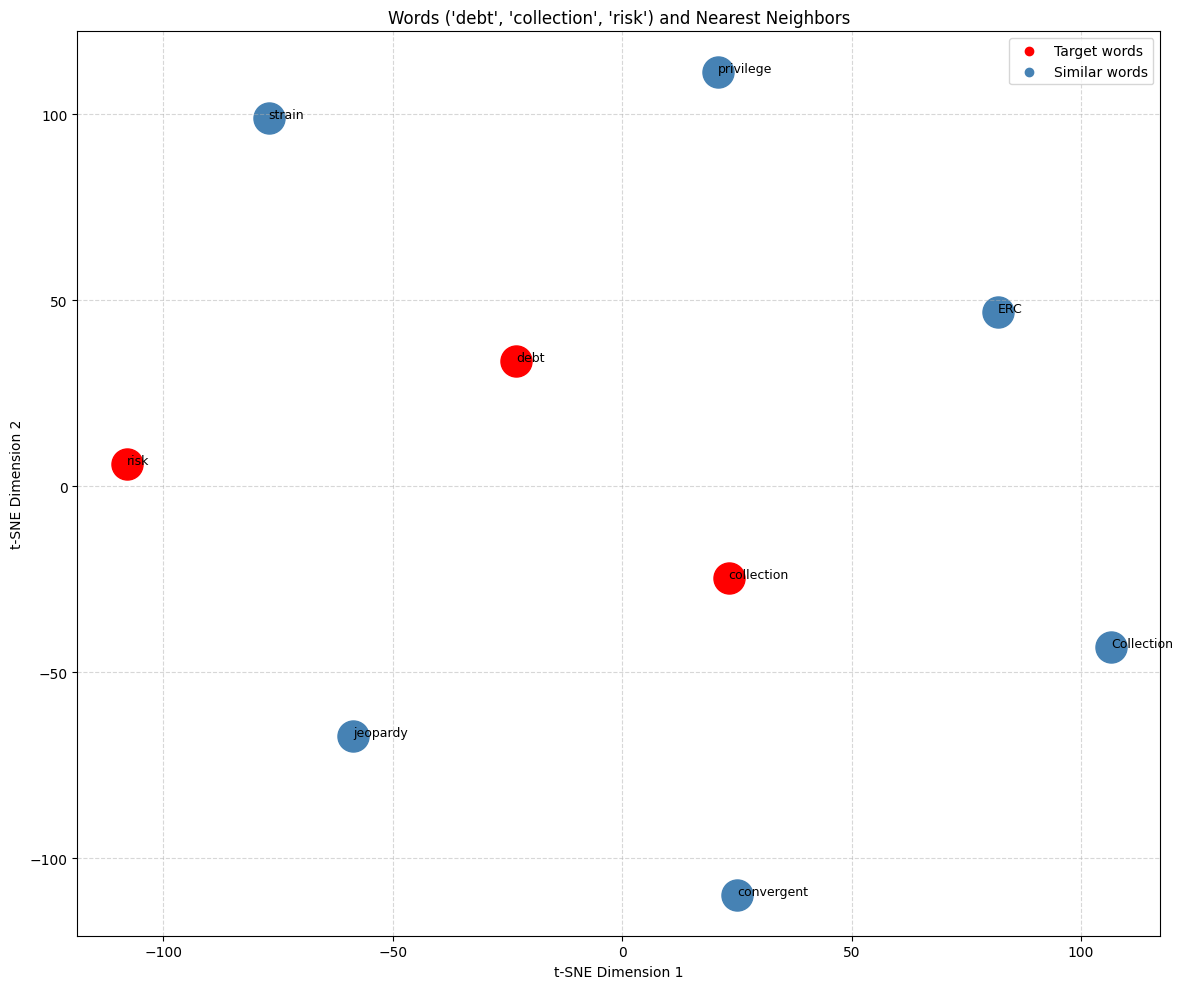

In [36]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

target_words = ['debt', 'collection', 'risk']

words_to_plot = set()

for word in target_words:
    words_to_plot.add(word)
    similar_words = model.wv.most_similar(word, topn=3)
    for sim_word, _ in similar_words:
        words_to_plot.add(sim_word)


words_to_plot = list(words_to_plot)


vectors = np.array([model.wv[word] for word in words_to_plot])


perplexity = len(vectors) - 1
tsne = TSNE(metric='cosine', n_components=2, random_state=42, perplexity=perplexity, )
vectors_2d = tsne.fit_transform(vectors)


plt.figure(figsize=(12, 10))
for i, word in enumerate(words_to_plot):
    # Highlight target words in red, others in blue
    color = 'red' if word in target_words else 'steelblue'
    plt.scatter(vectors_2d[i, 0], vectors_2d[i, 1], c=color, s=500)
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=9)

# Add legend
plt.scatter([], [], c='red', label='Target words')
plt.scatter([], [], c='steelblue', label='Similar words')
plt.legend()
plt.title("Words ('debt', 'collection', 'risk') and Nearest Neighbors")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Reflection

> Due to very large dataset (500k), the time required to perform preprocessing, text cleaning, and model training is significantly long, so I decided to trim out only first 50k rows to ensure that the model can train in time.
>
> The text are clean and preprocessed, but their are some minor noise and errors. (I observed some token like `againTHANKYOU`, maybe a typo from customers)
>
> The `ERC`, `AFNI` seems like the agencies that perform debt management (from what I've searched the internet), so it is related to the word `debt`.